In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # dont write print to show result

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("loan.csv")
df.shape

(614, 13)

In [4]:
df=df.iloc[:,1:]

In [5]:
pd.set_option('display.max_rows', 15)
df.sample(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
342,Male,Yes,1,Not Graduate,No,4554,1229.0,158.0,360.0,1.0,Urban,Y
15,Male,No,0,Graduate,No,4950,0.0,125.0,360.0,1.0,Urban,Y
597,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
31,Male,No,0,Graduate,No,3167,0.0,74.0,360.0,1.0,Urban,N
484,Male,Yes,2,Graduate,No,8333,0.0,246.0,360.0,1.0,Semiurban,Y
476,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,Y
410,Female,No,1,Not Graduate,Yes,3867,0.0,62.0,360.0,1.0,Semiurban,N
296,Male,Yes,1,Graduate,No,6875,0.0,200.0,360.0,1.0,Semiurban,Y
344,Male,Yes,2,Graduate,NaN,2583,2330.0,125.0,360.0,1.0,Rural,Y
433,Male,Yes,0,Graduate,No,2425,2340.0,143.0,360.0,1.0,Semiurban,Y


In [6]:
df.describe()
df.duplicated().sum()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


0

In [7]:
df["Self_Employed"].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [9]:
df.corr()

ValueError: could not convert string to float: 'Male'

# NAN Value treatment

In [ ]:
(df.isnull().sum()/df.shape[0])*100

In [10]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['Gender', 'Married', 'Dependents', 'LoanAmount', 'Loan_Amount_Term']

In [11]:
df[cols].sample(5)

,Gender,Married,Dependents,LoanAmount,Loan_Amount_Term
486,Male,No,2,80.0,360.0
536,Male,Yes,0,324.0,360.0
322,Male,Yes,2,NaN,360.0
462,Male,Yes,0,153.0,360.0
448,Male,Yes,2,150.0,360.0


In [12]:
len(df[cols].dropna()) / len(df)

0.9006514657980456

In [13]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((614, 12), (553, 5))

array([[<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'Loan_Amount_Term'}>]], dtype=object)

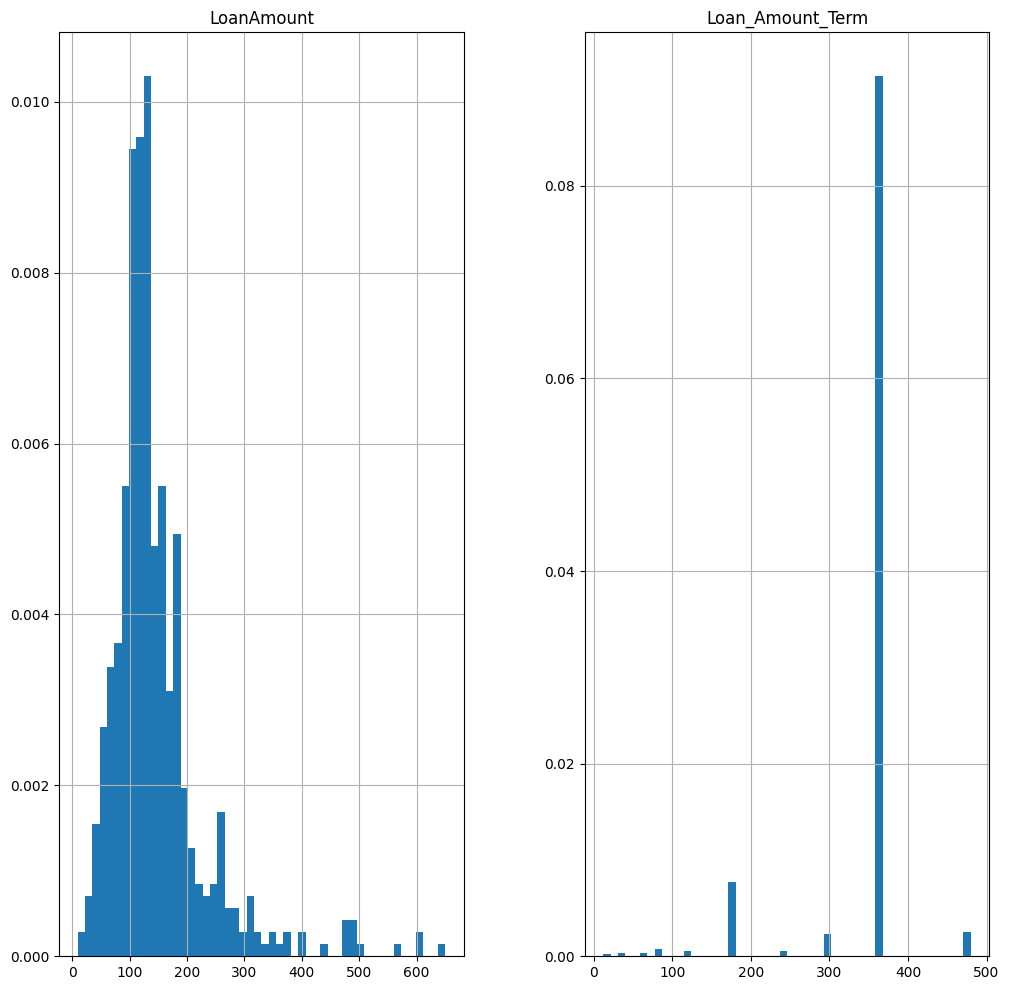

In [14]:
new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

<Axes: >

<Axes: >

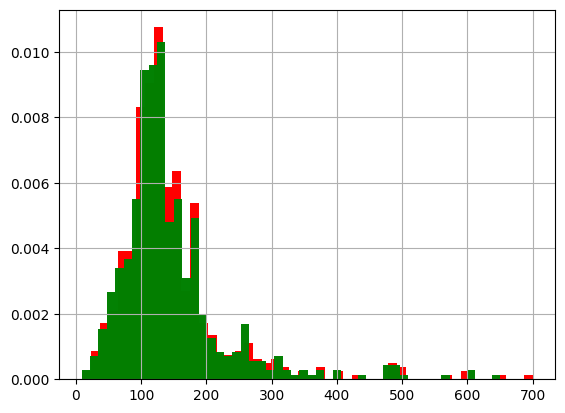

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['LoanAmount'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['LoanAmount'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.99)

<Axes: >

<Axes: >

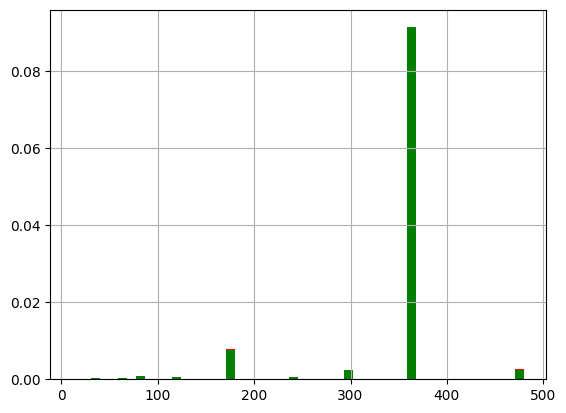

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['Loan_Amount_Term'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['Loan_Amount_Term'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.99)

<Axes: ylabel='Density'>

<Axes: ylabel='Density'>

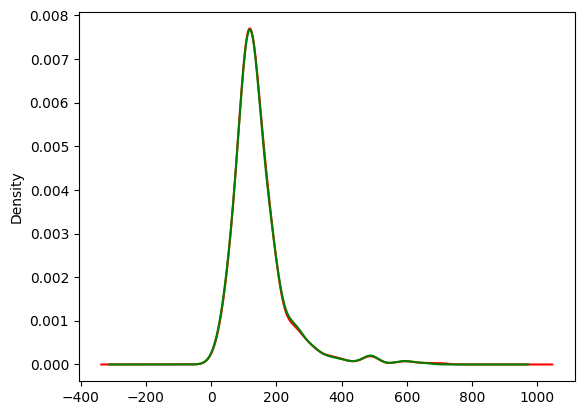

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['LoanAmount'].plot.density(color='red')

# data after cca
new_df['LoanAmount'].plot.density(color='green')

<Axes: ylabel='Density'>

<Axes: ylabel='Density'>

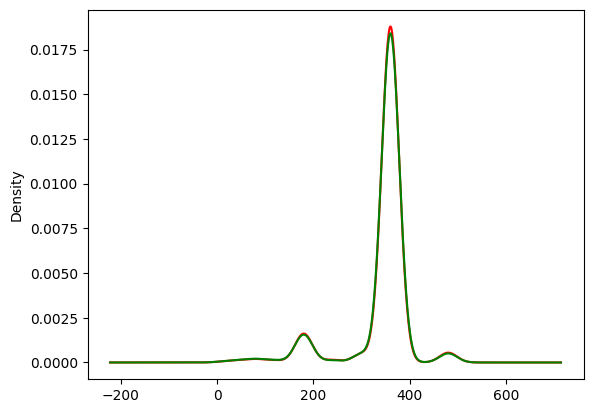

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['Loan_Amount_Term'].plot.density(color='red')

# data after cca
new_df['Loan_Amount_Term'].plot.density(color='green')

In [19]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['Gender'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['Gender'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
Gender,,
Male,0.796417,0.811935
Female,0.182410,0.188065


In [20]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['Married'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['Married'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
Married,,
Yes,0.648208,0.649186
No,0.346906,0.350814


In [21]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['Dependents'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['Dependents'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
Dependents,,
0,0.561889,0.571429
1,0.166124,0.173599
2,0.164495,0.173599
3+,0.083062,0.081374


In [22]:
df.dropna(subset=['Married', 'Dependents'], inplace=True)
df.shape


(599, 12)

In [23]:
(df.isnull().sum()/df.shape[0])*100

Gender               2.170284
Married              0.000000
Dependents           0.000000
Education            0.000000
Self_Employed        5.342237
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.338898
Loan_Amount_Term     2.170284
Credit_History       8.347245
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

<Axes: ylabel='Density'>

<Axes: ylabel='Density'>

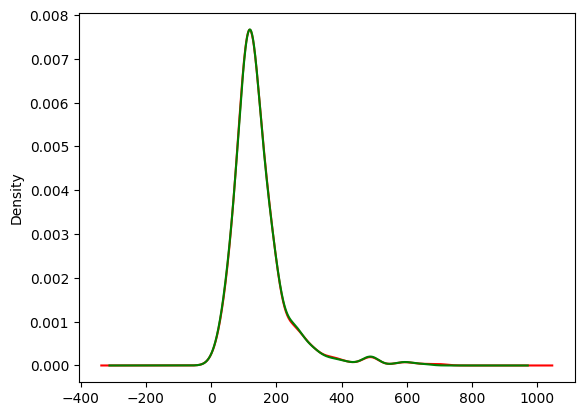

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['LoanAmount'].plot.density(color='red')

# data after cca
new_df['LoanAmount'].plot.density(color='green')

In [25]:
df['Credit_History'].mode()

0    1.0
Name: Credit_History, dtype: float64

In [26]:
df.isnull().sum()

Gender               13
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           20
Loan_Amount_Term     13
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [35]:
# Step 2: Drop rows with any null values
df_dropped_rows = df.dropna()
# print("\nDataFrame after dropping rows with null values:\n", df_dropped_rows)

# 


In [36]:
df_dropped_rows.shape

(480, 12)

In [38]:
df_dropped_rows.to_csv('Loan.csv', index=False)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             586 non-null    object 
 1   Married            599 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          599 non-null    object 
 4   Self_Employed      567 non-null    object 
 5   ApplicantIncome    599 non-null    int64  
 6   CoapplicantIncome  599 non-null    float64
 7   LoanAmount         579 non-null    float64
 8   Loan_Amount_Term   586 non-null    float64
 9   Credit_History     549 non-null    float64
 10  Property_Area      599 non-null    object 
 11  Loan_Status        599 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 60.8+ KB
